In [76]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from pygam import LogisticGAM, s, f

In [77]:
#5.1
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [78]:
# 1 Logistic Regression
lr = LogisticRegression(penalty=None).fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
lr_loss = log_loss(y_test, lr.predict_proba(X_test))

# 2 LDA
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
lda_acc = accuracy_score(y_test, lda.predict(X_test))
lda_loss = log_loss(y_test, lda.predict_proba(X_test))

# 3 QDA
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
qda_acc = accuracy_score(y_test, qda.predict(X_test))
qda_loss = log_loss(y_test, qda.predict_proba(X_test))

# 4 Gaussian Naive Bayes
gnb = GaussianNB().fit(X_train, y_train)
gnb_acc = accuracy_score(y_test, gnb.predict(X_test))
gnb_loss = log_loss(y_test, gnb.predict_proba(X_test))

print(f"Logistic Reg - Acc: {lr_acc:.4f}, Loss: {lr_loss:.4f}")
print(f"LDA          - Acc: {lda_acc:.4f}, Loss: {lda_loss:.4f}")
print(f"QDA          - Acc: {qda_acc:.4f}, Loss: {qda_loss:.4f}")
print(f"Gaussian NB  - Acc: {gnb_acc:.4f}, Loss: {gnb_loss:.4f}")

Logistic Reg - Acc: 0.8108, Loss: 0.3660
LDA          - Acc: 0.7838, Loss: 0.3591
QDA          - Acc: 0.7568, Loss: 0.5976
Gaussian NB  - Acc: 0.7297, Loss: 0.5164


/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


We noticed that all models show relatively similar accuracy, ranging from ~73% to ~81%. However, we might withness that the Log Loss for QDA (0.5976) and Gaussian NB (0.5164) is quite higher when compared to Logistic Regression and LDA. Perhaps this happens because models like QDA and Gaussian NB have a highly sensitive to violations of their underlying distributional assumptions. These leads to high Log Loss, while the same Accuracy. 

In [79]:
#5.2
gam = LogisticGAM(f(0) + f(1) + s(2) + s(3)).fit(X_train, y_train)

gam_preds = gam.predict(X_test)
gam_probs = gam.predict_proba(X_test)

gam_acc = accuracy_score(y_test, gam_preds)
gam_loss = log_loss(y_test, gam_probs)

print(f"GAM Accuracy: {gam_acc:.4f}")
print(f"GAM Log Loss: {gam_loss:.4f}")

GAM Accuracy: 0.8649
GAM Log Loss: 0.3375


Text(0.5, 0, 'Value (0, 1, 2)')

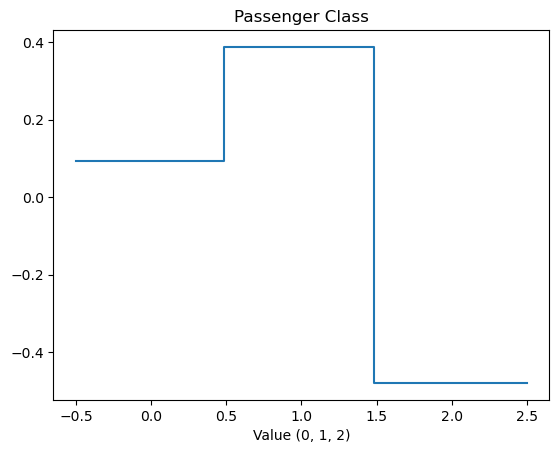

In [80]:
XX_class = gam.generate_X_grid(term=0)
p_class, conf_class = gam.partial_dependence(term=0, X=XX_class, width=0.95)
plt.step(XX_class[:, 0], p_class, where='mid', label='Partial Dep.')

plt.title('Passenger Class')
plt.xlabel('Value (0, 1, 2)')

Text(0.5, 0, 'Value (0=F, 1=M)')

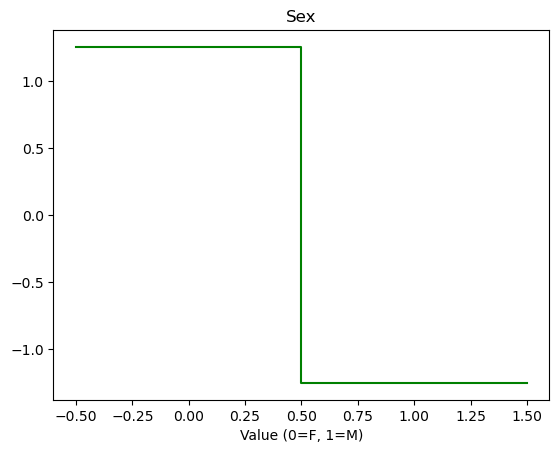

In [81]:
XX_sex = gam.generate_X_grid(term=1)
p_sex, conf_sex = gam.partial_dependence(term=1, X=XX_sex, width=0.95)
plt.step(XX_sex[:, 1], p_sex, where='mid', color='green')
plt.title('Sex')
plt.xlabel('Value (0=F, 1=M)')

Text(0.5, 0, 'Years')

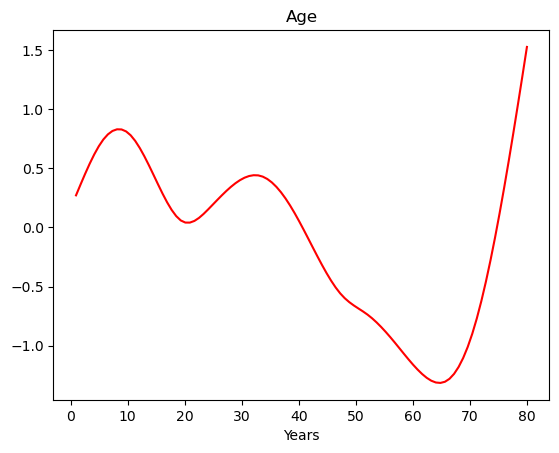

In [82]:
XX_age = gam.generate_X_grid(term=2)
p_age, conf_age = gam.partial_dependence(term=2, X=XX_age, width=0.95)
plt.plot(XX_age[:, 2], p_age, color='red')
plt.title('Age')
plt.xlabel('Years')

Text(0.5, 0, 'Ticket Price')

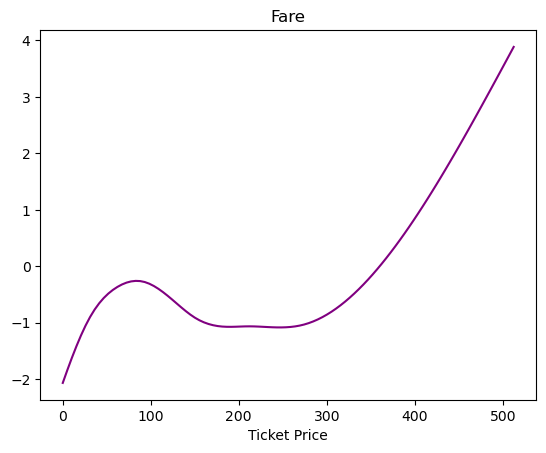

In [83]:
XX_fare = gam.generate_X_grid(term=3)
p_fare, conf_fare = gam.partial_dependence(term=3, X=XX_fare, width=0.95)
plt.plot(XX_fare[:, 3], p_fare, color='purple')
plt.title('Fare')
plt.xlabel('Ticket Price')

5.3
Survival log-odds decrease as the class index moves from 0 to 2, which shows that higher-class significantly improved survival chances.

There is a sharp negative step from 0 to 1, demonstrating that being female was one of the strongest predictors for survival.

The spline shows higher survival rate for young children, while a bit lower for young adults. And then there is another increase towards aged people (70+)

Last but not least, the survival probability increases with the fare paid. Though the spline might show diminishing returns.